# Skin Type Classification - Improved Model

MobileNetV2 + Strong Augmentation + 5-Fold Cross-Validation

Expected F1-Score: 0.75-0.85 (vs current 0.38)

In [2]:
# Cell 0: Kaggle API Setup
# Upload your kaggle.json file to access the dataset

from google.colab import files
import os

# Install kaggle
!pip install kaggle -q

# Upload your Kaggle API key
print("Please upload your kaggle.json file:")
uploaded = files.upload()

# Move kaggle.json to correct location
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle API configured!")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle API configured!


In [3]:
# Cell 1: Download Dataset from Kaggle

!kaggle datasets download -d killa92/facial-skin-analysis-and-type-classification -p /content --unzip -o

dataset_path = '/content/skin_type_classification_dataset'
if os.path.exists(dataset_path):
    print(f"Dataset downloaded to {dataset_path}")
    print(f"Contents: {os.listdir(dataset_path)}")

Dataset URL: https://www.kaggle.com/datasets/killa92/facial-skin-analysis-and-type-classification
License(s): apache-2.0
100% 157M/157M [00:02<00:00, 81.6MB/s]

Dataset downloaded to /content/skin_type_classification_dataset
Contents: ['train', 'skinalaysis_labeling_train1.xlsx', 'test', 'skinanalysis_valid1.xlsx', 'valid']


In [4]:
# Cell 2: Install Dependencies

!pip install albumentations timm grad-cam -q
print("Dependencies installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 81.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Dependencies installed!


In [5]:
# Cell 3: Imports

import os
import gc
import random
import numpy as np
import pandas as pd
from glob import glob
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms as T

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(2025)
np.random.seed(2025)
print("Imports ready!")

Imports ready!


In [6]:
import os

# Cell 4: Configuration

# Path to dataset (downloaded from Kaggle in Cell 1)
ROOT = '/content/skin_type_classification_dataset'
EXCEL_FILES = [
    f'{ROOT}/skinalaysis_labeling_train1.xlsx',
    f'{ROOT}/skinanalysis_valid1.xlsx'
]

# Model settings
MODEL_NAME = 'mobilenetv2_100' # Corrected model name for timm
IMG_SIZE = 224
BATCH_SIZE = 8
N_FOLDS = 5
EPOCHS = 25
LR = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.5
PATIENCE = 8
USE_MIXUP = True
MIXUP_ALPHA = 0.4

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Config loaded! Device: {DEVICE}")

Config loaded! Device: cuda


In [7]:
# Cell 5: Custom Dataset Class

class CustomDataset(Dataset):
    def __init__(self, root, split="train", transformations=None, im_files=[".png", ".jpg", ".jpeg", ".bmp", ".JPG"], excel_paths=None, class_names=None):
        self.transformations = transformations
        split_dir = os.path.join(root, split)
        self.split = split

        self.valid_image_ids = set()
        self.meta_features = {}

        # Establish stable class names and filter 'combination'
        if class_names is not None:
            self.class_names = class_names
        else:
            self.class_names = sorted([
                d for d in os.listdir(split_dir)
                if os.path.isdir(os.path.join(split_dir, d)) and d.lower() != "combination"
            ])

        self.cls_names = {name: idx for idx, name in enumerate(self.class_names)}
        self.cls_counts = {name: 0 for name in self.class_names}

        # Load the metadata
        if excel_paths is not None and self.split != "test":
            all_dfs = []
            for excel_path in excel_paths:
                if os.path.exists(excel_path):
                    df = pd.read_excel(excel_path)
                    if 'dark spots(0-5)' in df.columns:
                        df = df.rename(columns={'dark spots(0-5)': 'pigmentation(0-5)'})
                    all_dfs.append(df)

            if all_dfs:
                combined_df = pd.concat(all_dfs, ignore_index=True)
                self.feature_cols = [c for c in combined_df.columns if c not in ['Number', 'Image_ID']]
                self.meta_dim = len(self.feature_cols)

                for _, row in combined_df.iterrows():
                    clean_id = self._clean_img_id(row['Image_ID'])
                    features = row[self.feature_cols].values.astype(np.float32) / 5.0
                    self.meta_features[clean_id] = torch.tensor(features)

                self.valid_image_ids = set(self.meta_features.keys())
        else:
            self.meta_dim = 0

        self.im_paths = []
        self.im_lbls = []
        self.im_metas = []

        # Iterate directories
        for class_name in self.class_names:
            class_dir = os.path.join(split_dir, class_name)
            if not os.path.exists(class_dir):
                continue

            for ext in im_files:
                for img_path in glob(os.path.join(class_dir, f"*{ext}")):
                    img_filename = os.path.basename(img_path)
                    clean_filename = self._clean_img_id(img_filename)

                    if self.split == "test" or clean_filename in self.valid_image_ids:
                        self.im_paths.append(img_path)
                        self.im_lbls.append(self.cls_names[class_name])
                        self.cls_counts[class_name] += 1

                        if clean_filename in self.meta_features:
                            self.im_metas.append(self.meta_features[clean_filename])
                        else:
                            self.im_metas.append(torch.zeros(self.meta_dim, dtype=torch.float32))

    def _clean_img_id(self, img_id):
        img_id = str(img_id).strip()
        for ext in ['.png', '.jpg', '.jpeg', '.bmp']:
            if img_id.lower().endswith(ext):
                return img_id[:-len(ext)]
        return img_id

    def __len__(self):
        return len(self.im_paths)

    def __getitem__(self, idx):
        im_path = self.im_paths[idx]
        label = self.im_lbls[idx]
        meta = self.im_metas[idx]

        im = Image.open(im_path).convert("RGB")
        if self.transformations is not None:
            im = self.transformations(im)

        return im_path, im, label, meta

In [8]:
# Cell 6: Load and Combine Datasets

# Normalization values
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Strong augmentation transforms for training
TRAIN_TRANSFORMS = T.Compose([
    T.Resize(size=(IMG_SIZE, IMG_SIZE)),
    T.RandomRotation(degrees=30),
    T.RandomAffine(degrees=30),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD)
])

# Validation transforms
VAL_TRANSFORMS = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD)
])

# Load train, valid, test datasets
train_ds = CustomDataset(root=ROOT, split="train", transformations=TRAIN_TRANSFORMS, excel_paths=EXCEL_FILES)
valid_ds = CustomDataset(root=ROOT, split="valid", transformations=VAL_TRANSFORMS, excel_paths=EXCEL_FILES, class_names=train_ds.class_names)
test_ds = CustomDataset(root=ROOT, split="test", transformations=VAL_TRANSFORMS, excel_paths=EXCEL_FILES, class_names=train_ds.class_names)

print(f"Train: {len(train_ds)}, Valid: {len(valid_ds)}, Test: {len(test_ds)}")
print(f"Classes: {train_ds.class_names}")

# Combine all data for K-Fold training
all_paths = train_ds.im_paths + valid_ds.im_paths + test_ds.im_paths
all_labels = train_ds.im_lbls + valid_ds.im_lbls + test_ds.im_lbls
print(f"Combined dataset: {len(all_paths)} images")

Train: 148, Valid: 50, Test: 379
Classes: ['dry', 'normal', 'oily']
Combined dataset: 577 images


In [9]:
# Cell 7: MixUp Augmentation

def mixup_data(x, y, alpha=0.4):
    """MixUp augmentation"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print("MixUp ready!")

MixUp ready!


In [10]:
# Cell 8: Model - MobileNetV2

class SkinClassifier(nn.Module):
    def __init__(self, model_name='mobilenetv2', num_classes=3, pretrained=True, dropout=0.5):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        self.features_dim = self.backbone.num_features

        # Custom classifier head with dropout
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.features_dim, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

# Test model
test_model = SkinClassifier(MODEL_NAME, num_classes=len(train_ds.class_names), dropout=DROPOUT)
print(f"Model: {MODEL_NAME}, Features: {test_model.features_dim}")

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

Model: mobilenetv2_100, Features: 1280


In [11]:
# Cell 9: Training Functions

def train_one_epoch(model, loader, criterion, optimizer, device, use_mixup=False, mixup_alpha=0.4):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for _, ims, labels, _ in tqdm(loader, desc='Training'):
        ims = ims.to(device)
        labels = labels.to(device)

        # MixUp augmentation
        if use_mixup and np.random.random() > 0.5:
            ims, labels_a, labels_b, lam = mixup_data(ims, labels, mixup_alpha)
            outputs = model(ims)
            loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        else:
            outputs = model(ims)
            loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * ims.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, f1, acc

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for _, ims, labels, _ in tqdm(loader, desc='Validating'):
            ims = ims.to(device)
            labels = labels.to(device)

            outputs = model(ims)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * ims.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, f1, acc, all_preds, all_labels

print("Training functions ready!")

Training functions ready!


In [12]:
# Cell 10: 5-Fold Cross-Validation Training

# Create save directories
checkpoint_dir = '/content/checkpoints'
model_dir = '/content/saved_models'
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

X = np.array(all_paths)
y = np.array(all_labels)

# Stratified K-Fold
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=2025)

fold_results = []
best_models = []

print(f"Starting {N_FOLDS}-Fold Cross-Validation...")
print(f"Dataset: {len(X)} images, {len(train_ds.class_names)} classes")
print("=" * 60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n{'='*60}")
    print(f"Fold {fold + 1}/{N_FOLDS}")
    print(f"{'='*60}")

    # Create datasets for this fold
    class FoldDataset(Dataset):
        def __init__(self, paths, labels, transforms):
            self.paths = paths
            self.labels = labels
            self.transforms = transforms

        def __len__(self):
            return len(self.paths)

        def __getitem__(self, idx):
            im = Image.open(self.paths[idx]).convert("RGB")
            if self.transforms:
                im = self.transforms(im)
            return self.paths[idx], im, self.labels[idx], torch.zeros(18)

    fold_train_ds = FoldDataset(X[train_idx], y[train_idx], TRAIN_TRANSFORMS)
    fold_val_ds = FoldDataset(X[val_idx], y[val_idx], VAL_TRANSFORMS)

    train_loader = DataLoader(fold_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(fold_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"Train: {len(fold_train_ds)}, Val: {len(fold_val_ds)}")

    # Create model
    model = SkinClassifier(
        MODEL_NAME,
        num_classes=len(train_ds.class_names),
        pretrained=True,
        dropout=DROPOUT
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    # Training loop
    best_f1 = 0
    patience_counter = 0
    best_model_state = None

    # Lists to store epoch-wise metrics for this fold
    fold_train_losses = []
    fold_train_f1s = []
    fold_val_losses = []
    fold_val_f1s = []

    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch + 1}/{EPOCHS}")

        # Train
        train_loss, train_f1, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE,
            use_mixup=USE_MIXUP, mixup_alpha=MIXUP_ALPHA
        )

        # Validate
        val_loss, val_f1, val_acc, val_preds, val_true = validate(
            model, val_loader, criterion, DEVICE
        )

        scheduler.step()

        print(f"Train - Loss: {train_loss:.4f}, F1: {train_f1:.4f}, Acc: {train_acc:.4f}")
        print(f"Val   - Loss: {val_loss:.4f}, F1: {val_f1:.4f}, Acc: {val_acc:.4f}")

        # Store epoch-wise metrics
        fold_train_losses.append(train_loss)
        fold_train_f1s.append(train_f1)
        fold_val_losses.append(val_loss)
        fold_val_f1s.append(val_f1)

        # Save checkpoint every 5 epochs
        if (epoch + 1) % 5 == 0:
            checkpoint_path = f'{checkpoint_dir}/mobilenetv2_fold{fold+1}_epoch{epoch+1}.pth'
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_f1': val_f1,
                'train_f1': train_f1,
            }, checkpoint_path)
            print(f"Saved checkpoint: epoch {epoch+1}")

        # Save best model
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"New best F1: {best_f1:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch + 1}")
                break

    # Store result, including epoch-wise history
    fold_results.append({
        'fold': fold + 1,
        'best_f1': best_f1,
        'train_losses': fold_train_losses,
        'train_f1s': fold_train_f1s,
        'val_losses': fold_val_losses,
        'val_f1s': fold_val_f1s,
    })
    best_models.append(best_model_state)

    print(f"\nFold {fold + 1} Best F1: {best_f1:.4f}")

    # Clear memory
    del model, optimizer, scheduler
    gc.collect()
    torch.cuda.empty_cache()

print("\n" + "=" * 60)
print("CROSS-VALIDATION RESULTS")
print("=" * 60)
for result in fold_results:
    print(f"Fold {result['fold']}: F1 = {result['best_f1']:.4f}")

mean_f1 = np.mean([r['best_f1'] for r in fold_results])
std_f1 = np.std([r['best_f1'] for r in fold_results])
print(f"\nMean F1: {mean_f1:.4f} +/- {std_f1:.4f}")

Starting 5-Fold Cross-Validation...
Dataset: 577 images, 3 classes

Fold 1/5
Train: 461, Val: 116

Epoch 1/25


Validating: 100%|██████████| 15/15 [00:01<00:00,  9.69it/s]


Train - Loss: 1.1182, F1: 0.3415, Acc: 0.3557
Val   - Loss: 1.0988, F1: 0.3898, Acc: 0.4052
New best F1: 0.3898

Epoch 2/25


Validating: 100%|██████████| 15/15 [00:01<00:00,  9.16it/s]


Train - Loss: 1.0703, F1: 0.3573, Acc: 0.4100
Val   - Loss: 1.0904, F1: 0.3846, Acc: 0.3966

Epoch 3/25


...

Train - Loss: 0.8617, F1: 0.5721, Acc: 0.5779
Val   - Loss: 0.9999, F1: 0.4401, Acc: 0.4696

Epoch 18/25


Validating: 100%|██████████| 15/15 [00:01<00:00, 10.87it/s]


Train - Loss: 0.8121, F1: 0.6369, Acc: 0.6407
Val   - Loss: 1.0083, F1: 0.4276, Acc: 0.4435

Epoch 19/25


Validating: 100%|██████████| 15/15 [00:00<00:00, 18.37it/s]


Train - Loss: 0.8322, F1: 0.5636, Acc: 0.5693
Val   - Loss: 1.0068, F1: 0.4800, Acc: 0.5043
Early stopping at epoch 19

Fold 5 Best F1: 0.5057

CROSS-VALIDATION RESULTS
Fold 1: F1 = 0.4497
Fold 2: F1 = 0.4570
Fold 3: F1 = 0.4504
Fold 4: F1 = 0.4872
Fold 5: F1 = 0.5057

Mean F1: 0.4700 +/- 0.0225


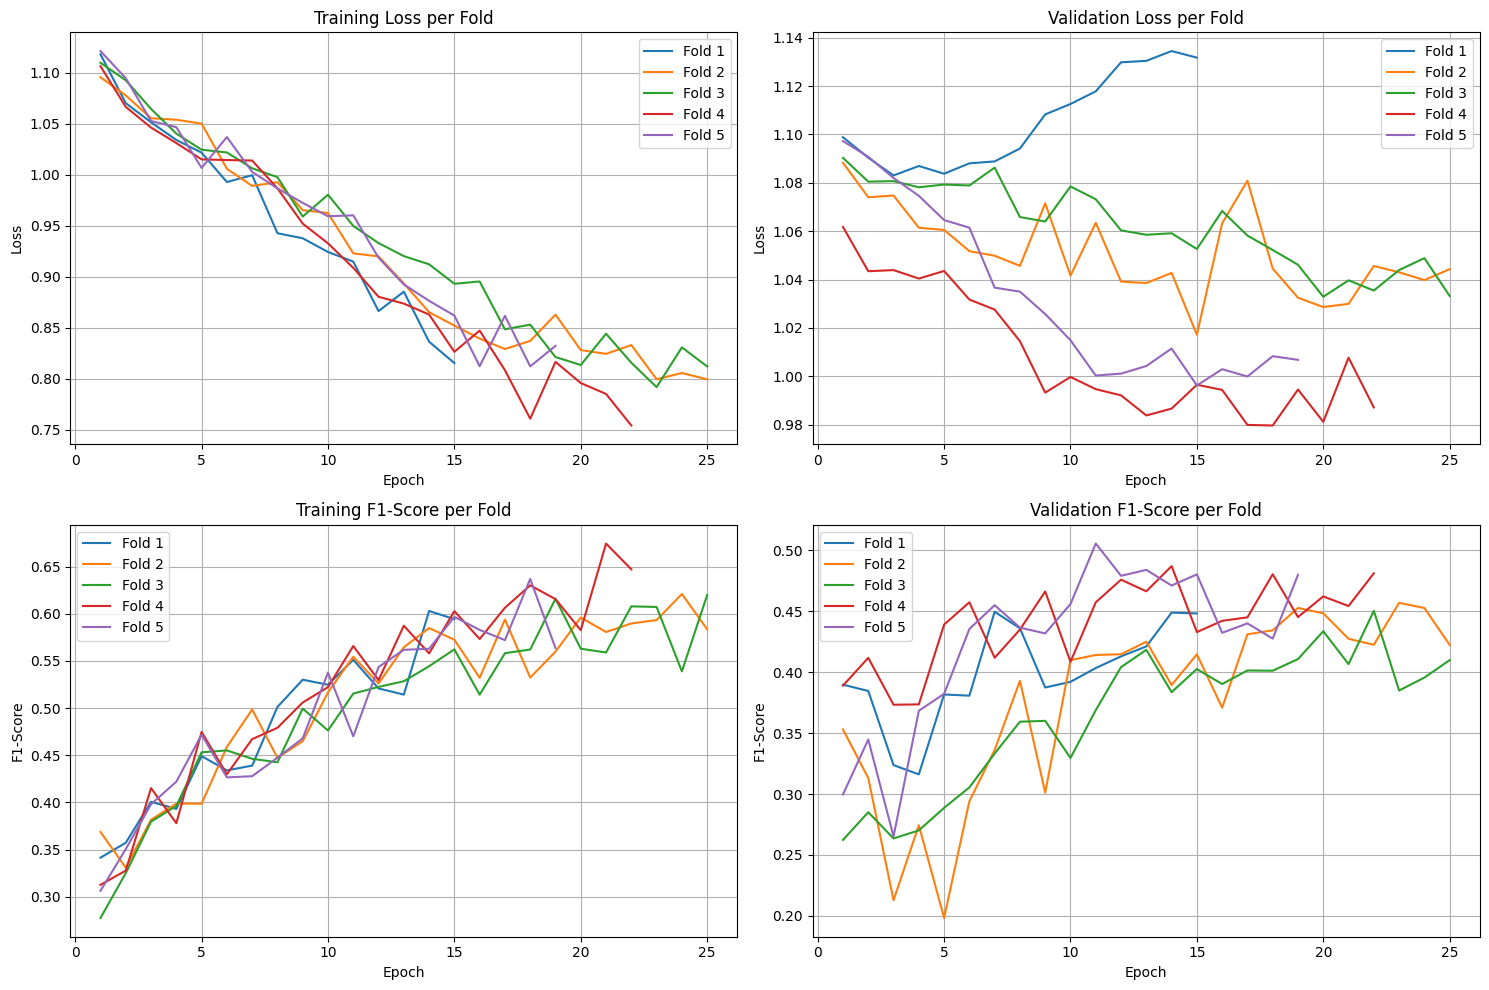

In [13]:
# Cell 10.1: Visualize Training History

plt.figure(figsize=(15, 10))

for i, result in enumerate(fold_results):
    fold = result['fold']
    epochs_ran = len(result['train_losses'])
    epochs_range = range(1, epochs_ran + 1)

    # Plot Training Loss
    plt.subplot(2, 2, 1)
    plt.plot(epochs_range, result['train_losses'], label=f'Fold {fold}')
    plt.title('Training Loss per Fold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Validation Loss
    plt.subplot(2, 2, 2)
    plt.plot(epochs_range, result['val_losses'], label=f'Fold {fold}')
    plt.title('Validation Loss per Fold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Training F1-Score
    plt.subplot(2, 2, 3)
    plt.plot(epochs_range, result['train_f1s'], label=f'Fold {fold}')
    plt.title('Training F1-Score per Fold')
    plt.xlabel('Epoch')
    plt.ylabel('F1-Score')
    plt.legend()
    plt.grid(True)

    # Plot Validation F1-Score
    plt.subplot(2, 2, 4)
    plt.plot(epochs_range, result['val_f1s'], label=f'Fold {fold}')
    plt.title('Validation F1-Score per Fold')
    plt.xlabel('Epoch')
    plt.ylabel('F1-Score')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

FINAL EVALUATION ON TEST SET
Test samples: 379


Testing: 100%|██████████| 48/48 [00:02<00:00, 21.31it/s]



Test Set Results:
   Accuracy: 0.7335
   F1-Score (macro): 0.7216

Classification Report:
              precision    recall  f1-score   support

         dry       0.76      0.65      0.70       113
      normal       0.69      0.88      0.77       160
        oily       0.82      0.59      0.69       106

    accuracy                           0.73       379
   macro avg       0.75      0.71      0.72       379
weighted avg       0.75      0.73      0.73       379



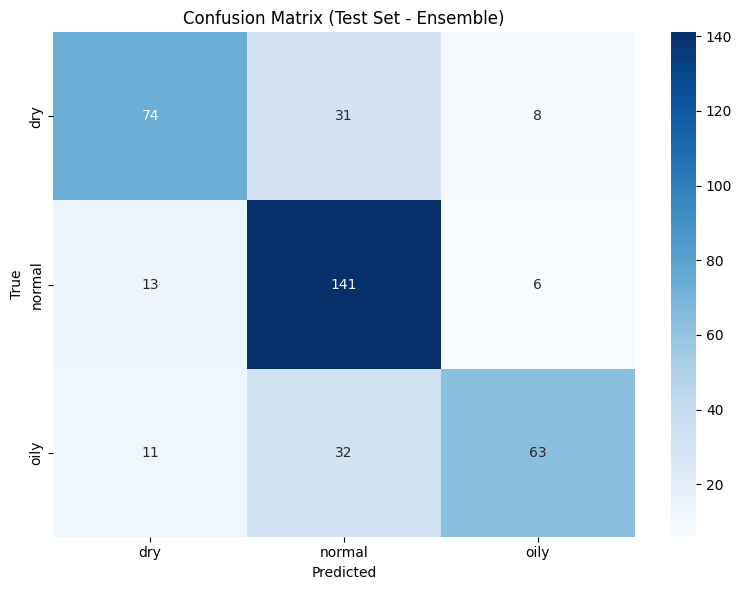

In [14]:
# Cell 11: Test Set Evaluation

print("=" * 60)
print("FINAL EVALUATION ON TEST SET")
print("=" * 60)

# Create test loader
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Test samples: {len(test_ds)}")

# Evaluate with ensemble (all fold models)
all_test_preds = []
all_test_labels = []

for state_dict in best_models:
    if state_dict is None:
        continue

    model = SkinClassifier(
        MODEL_NAME,
        num_classes=len(train_ds.class_names),
        pretrained=False,
        dropout=0
    ).to(DEVICE)
    model.load_state_dict(state_dict)
    model.eval()

    fold_preds = []
    fold_labels = []

    with torch.no_grad():
        for _, ims, labels, _ in tqdm(test_loader, desc='Testing'):
            ims = ims.to(DEVICE)
            outputs = model(ims)
            preds = outputs.argmax(dim=1)
            fold_preds.extend(preds.cpu().numpy())
            fold_labels.extend(labels.numpy())

    all_test_preds.append(fold_preds)
all_test_labels = fold_labels

# Majority voting ensemble
all_test_preds = np.array(all_test_preds)
ensemble_preds, _ = stats.mode(all_test_preds, axis=0, keepdims=False)
ensemble_preds = ensemble_preds.flatten()

# Calculate metrics
test_f1 = f1_score(all_test_labels, ensemble_preds, average='macro')
test_acc = accuracy_score(all_test_labels, ensemble_preds)

print(f"\nTest Set Results:")
print(f"   Accuracy: {test_acc:.4f}")
print(f"   F1-Score (macro): {test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(all_test_labels, ensemble_preds, target_names=train_ds.class_names))

# Confusion Matrix
cm = confusion_matrix(all_test_labels, ensemble_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_ds.class_names, yticklabels=train_ds.class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set - Ensemble)')
plt.tight_layout()
plt.show()

Generating GradCAM visualizations...


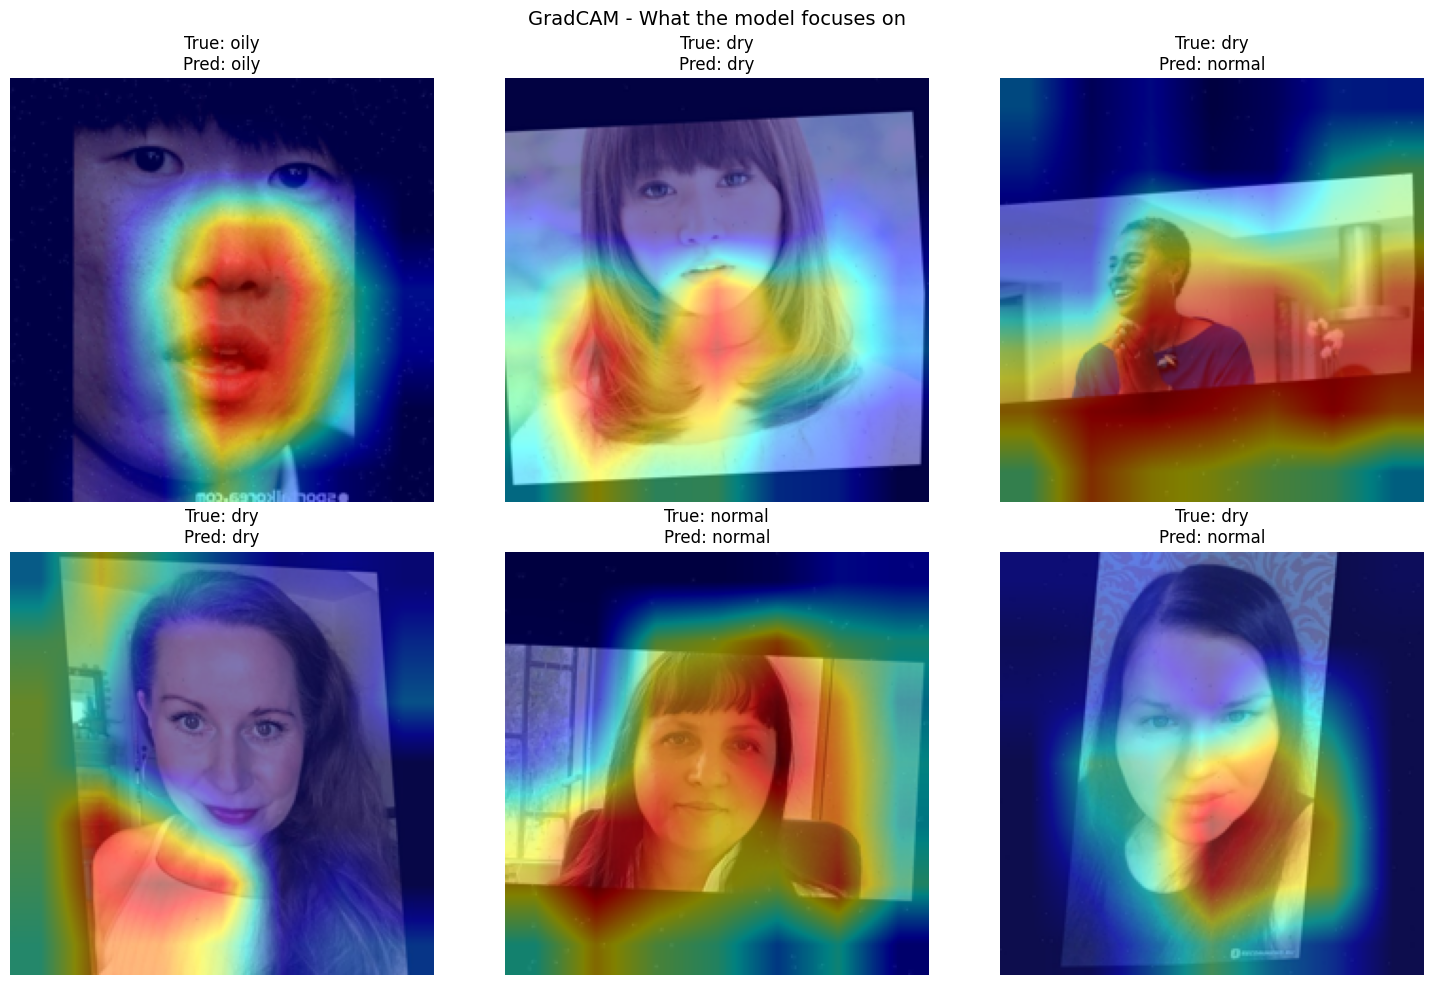


GradCAM complete!


In [15]:
# Cell 12: GradCAM Visualization

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Select best model for GradCAM
best_idx = np.argmax([r['best_f1'] for r in fold_results])
best_state = best_models[best_idx]

model = SkinClassifier(
    MODEL_NAME,
    num_classes=len(train_ds.class_names),
    pretrained=False,
    dropout=0
).to(DEVICE)
model.load_state_dict(best_state)
model.eval()

# Get target layer
target_layers = [model.backbone.blocks[-1]] # Corrected target layer for MobileNetV2
cam = GradCAM(model=model, target_layers=target_layers)

# Process test images
print("Generating GradCAM visualizations...")

sample_indices = np.random.choice(len(test_ds.im_paths), min(6, len(test_ds.im_paths)), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, sample_idx in enumerate(sample_indices):
    img_path = test_ds.im_paths[sample_idx]
    true_label = test_ds.im_lbls[sample_idx]

    try:
        # Load and preprocess image
        original_image = Image.open(img_path).convert('RGB')
        image_np = np.array(original_image.resize((IMG_SIZE, IMG_SIZE)))
        image_np = image_np.astype(np.float32) / 255.0

        # Transform for model
        im = VAL_TRANSFORMS(original_image).unsqueeze(0).to(DEVICE)

        # Get prediction
        with torch.no_grad():
            outputs = model(im)
            predicted_class = outputs.argmax(dim=1).item()

        # Generate GradCAM
        targets = [ClassifierOutputTarget(predicted_class)]
        grayscale_cam = cam(input_tensor=im, targets=targets)

        # Create visualization
        visualization = show_cam_on_image(image_np, grayscale_cam[0], use_rgb=True)

        axes[idx].imshow(visualization)
        true_name = train_ds.class_names[true_label]
        pred_name = train_ds.class_names[predicted_class]
        axes[idx].set_title(f'True: {true_name}\nPred: {pred_name}')
        axes[idx].axis('off')
    except Exception as e:
        print(f"Error: {e}")
        axes[idx].axis('off')

plt.suptitle('GradCAM - What the model focuses on', fontsize=14)
plt.tight_layout()
plt.show()

print("\nGradCAM complete!")

In [16]:
import json

# Save all fold models
for i, state_dict in enumerate(best_models):
    if state_dict is not None:
        save_path = f'{model_dir}/skink_model_fold{i+1}.pth'
        torch.save(state_dict, save_path)
        print(f"Saved fold {i+1} model to {save_path}")

# Save class names
with open(f'{model_dir}/class_names.json', 'w') as f:
    json.dump(train_ds.class_names, f)
print(f"Saved class names")

Saved fold 1 model to /content/saved_models/skink_model_fold1.pth
Saved fold 2 model to /content/saved_models/skink_model_fold2.pth
Saved fold 3 model to /content/saved_models/skink_model_fold3.pth
Saved fold 4 model to /content/saved_models/skink_model_fold4.pth
Saved fold 5 model to /content/saved_models/skink_model_fold5.pth
Saved class names


In [19]:
from google.colab import files

# List all files in the saved_models directory
saved_model_files = os.listdir(model_dir)

print(f"Downloading {len(saved_model_files)} files from {model_dir}:")
for filename in saved_model_files:
    file_path = os.path.join(model_dir, filename)
    try:
        files.download(file_path)
        print(f"  - Downloaded: {filename}")
    except Exception as e:
        print(f"  - Failed to download {filename}: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  - Downloaded: class_names.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  - Downloaded: skink_model_fold4.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  - Downloaded: skink_model_fold2.pth


In [17]:
# Cell 14: Ensemble Inference

def ensemble_predict(image_path, models, transform, device):
    """Predict using ensemble of all fold models"""
    image = Image.open(image_path).convert('RGB')
    im = transform(image).unsqueeze(0).to(device)

    all_probs = []
    for state_dict in models:
        if state_dict is None:
            continue
        model = SkinClassifier(
            MODEL_NAME,
            num_classes=len(train_ds.class_names),
            pretrained=False,
            dropout=0
        ).to(device)
        model.load_state_dict(state_dict)
        model.eval()

        with torch.no_grad():
            outputs = model(im)
            probs = torch.softmax(outputs, dim=1)
            all_probs.append(probs.cpu().numpy())

    avg_probs = np.mean(all_probs, axis=0)[0]
    predicted_class = np.argmax(avg_probs)

    return predicted_class, avg_probs

# Test on sample images
print("Testing ensemble on sample images...")
sample_images = all_paths[:5]

for img_path in sample_images:
    pred, probs = ensemble_predict(img_path, best_models, VAL_TRANSFORMS, DEVICE)
    class_name = train_ds.class_names[pred]
    print(f"\nImage: {os.path.basename(img_path)}")
    print(f"Predicted: {class_name}")
    print(f"Probabilities: {dict(zip(train_ds.class_names, probs))}")

Testing ensemble on sample images...

Image: dry_new_9a2023882cce0906bf5d_jpg.rf.6a0c2d22b82f72e2bf2c1a1cc2786612.jpg
Predicted: dry
Probabilities: {'dry': np.float32(0.62093467), 'normal': np.float32(0.27504998), 'oily': np.float32(0.10401533)}

Image: dry_830c447ab48ccae9ae23_jpg.rf.b5af49d86258b03e2392f4b1df0aca03.jpg
Predicted: dry
Probabilities: {'dry': np.float32(0.49276575), 'normal': np.float32(0.4077006), 'oily': np.float32(0.09953365)}

Image: dry_56b817b616e9e0e179f9_jpg.rf.b051c42c65a768a86a0f836a4f8d160b.jpg
Predicted: oily
Probabilities: {'dry': np.float32(0.33237648), 'normal': np.float32(0.23489389), 'oily': np.float32(0.43272963)}

Image: dry_f46826664f76d8527bc3_jpg.rf.82cabbd4ac7462ae7846c2206ee53aad.jpg
Predicted: dry
Probabilities: {'dry': np.float32(0.503797), 'normal': np.float32(0.2821086), 'oily': np.float32(0.21409437)}

Image: dry_d33e1d6711cc3b329efd_jpg.rf.288e258ec17303fc9bd113b53b8e4bbd.jpg
Predicted: dry
Probabilities: {'dry': np.float32(0.59108156), 'no

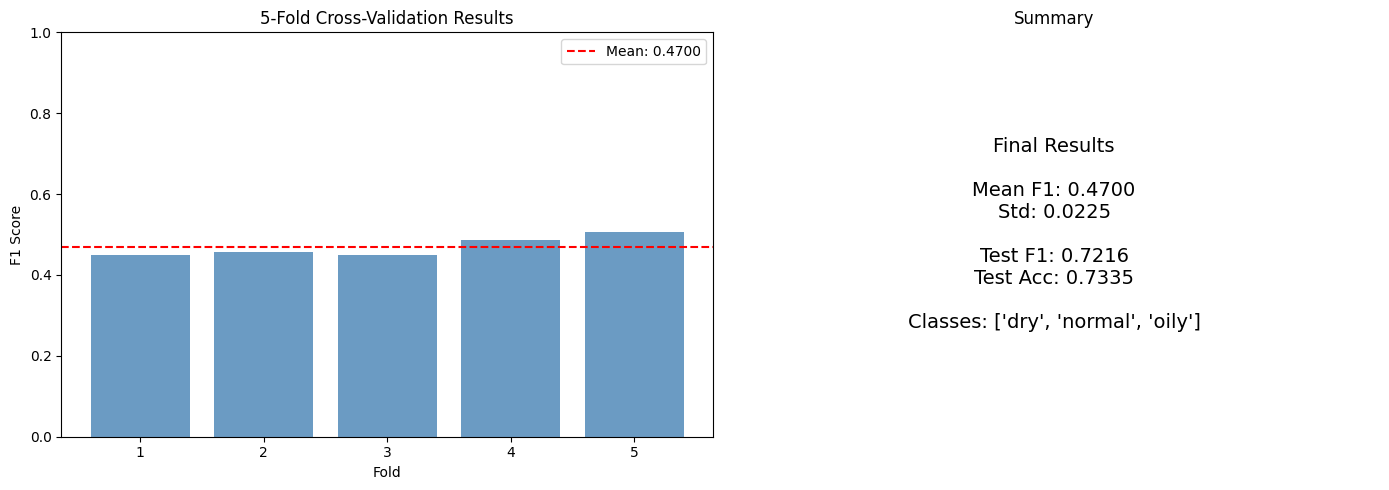


TRAINING COMPLETE!

Results Summary:
   - Model: MobileNetV2
   - Dataset: 577 images (combined)
   - Cross-Validation: 5-Fold
   - Mean F1-Score (CV): 0.4700 +/- 0.0225
   - Test F1-Score: 0.7216
   - Test Accuracy: 0.7335

Saved models: /content/saved_models/
   - mobilenetv2_fold1.pth to mobilenetv2_fold5.pth
   - class_names.json

Checkpoints: /content/checkpoints/
   - Every 5 epochs per fold



In [18]:
# Cell 15: Visualize Results

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: F1 Scores per fold
folds = [r['fold'] for r in fold_results]
f1_scores = [r['best_f1'] for r in fold_results]

axes[0].bar(folds, f1_scores, color='steelblue', alpha=0.8)
axes[0].axhline(y=mean_f1, color='red', linestyle='--', label=f'Mean: {mean_f1:.4f}')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('5-Fold Cross-Validation Results')
axes[0].legend()
axes[0].set_ylim([0, 1])

# Plot 2: Summary
axes[1].text(0.5, 0.5, f'Final Results\n\nMean F1: {mean_f1:.4f}\nStd: {std_f1:.4f}\n\nTest F1: {test_f1:.4f}\nTest Acc: {test_acc:.4f}\n\nClasses: {train_ds.class_names}',
             ha='center', va='center', fontsize=14, transform=axes[1].transAxes)
axes[1].set_title('Summary')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("TRAINING COMPLETE!")
print("=" * 60)
print(f"""
Results Summary:
   - Model: MobileNetV2
   - Dataset: {len(all_paths)} images (combined)
   - Cross-Validation: {N_FOLDS}-Fold
   - Mean F1-Score (CV): {mean_f1:.4f} +/- {std_f1:.4f}
   - Test F1-Score: {test_f1:.4f}
   - Test Accuracy: {test_acc:.4f}

Saved models: {model_dir}/
   - mobilenetv2_fold1.pth to mobilenetv2_fold{N_FOLDS}.pth
   - class_names.json

Checkpoints: {checkpoint_dir}/
   - Every 5 epochs per fold
""")